# Supplementary Figure S9: Decorated MERA VFPE

Supplementary Figure S9 evaluates vector fixed point equation diagnostics for decorated MERA boundary states.

This figure includes:

* (a) VFPE residual $\sigma(K_\Delta)$ versus squeezing for several depths
* (b) fixed-$\mu$ convergence of $\sigma(K_\Delta)$ with depth $R_b$
* (c) comparison between the $K_\Delta$ central-charge estimate and the entropy-fit central charge

## Import Dependencies and Set Parameters

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import hashlib
import json
import os
import pickle
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

import loadconfig as loco
from graph2grav.figure_hashing import save_figure_with_hash
import graph2grav.plotting as plotting
from graph2grav.analysis import Analysis

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})
subfigure_label_fontsize = config["subfigure-label"]["font"]["size"]
COLORS = {
    "bulk": config["graph"]["nodes"]["ancilla"]["outer"]["color"],
    "boundary": config["graph"]["nodes"]["boundary"]["outer"]["color"],
    "selected": config["graph"]["nodes"]["selected_boundary"]["outer"]["color"],
    "selected_fill": config["graph"]["nodes"]["selected_boundary"]["inner"]["color"],
    "positive": config["decorated-figure"]["edges"]["positive"]["color"],
    "negative": config["decorated-figure"]["edges"]["negative"]["color"],
}
from graph2grav.graphs.standard import subdivided_tree_decoration_1
from graph2grav.vfpe import (
    balanced_four_arc_lengths,
    boundary_covariance_for_vfpe_from_graph,
    c_delta_residual_from_covariance,
    vfpe_residual_from_covariance,
)

FIGURE_PATH = Path("figures/supplementary-figure_decorated-mera-vfpe.pdf")
COMPARISON_FIGURE_PATH = Path("figures/supplementary-figure_decorated-mera-vfpe-c-comparison.pdf")
CACHE_DIR = Path("outputs/notebook_cache/S11_decorated_mera_vfpe")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 1
USE_NOTEBOOK_CACHE = True
CLEAR_NOTEBOOK_CACHE = False
COUPLING_TIME = 1.0
MU_VALUES = np.geomspace(0.01, 1.0, 13)
DEPTHS = (3, 4, 5, 6)
CONVERGENCE_DEPTHS = (3, 4, 5, 6)
FIXED_MU_FOR_CONVERGENCE = 0.01
PURE_MODE_FLOOR = 1e-10
BULK_WEIGHT = 1.0
BOUNDARY_WEIGHT = 1.0












## Define VFPE Helpers

Build decorated MERA graphs and compute cached VFPE residual rows.

In [2]:
def decorated_mera(depth):
    return subdivided_tree_decoration_1(
        depth,
        draw=False,
        bulk_weight=BULK_WEIGHT,
        probe_weight=BOUNDARY_WEIGHT,
    )


def vfpe_row(depth, mu):
    graph = decorated_mera(depth)
    covariance = boundary_covariance_for_vfpe_from_graph(
        graph,
        couplingtime=COUPLING_TIME,
        global_presqueeze=mu,
        is_decorated=True,
    )
    arcs = balanced_four_arc_lengths(covariance.shape[0] // 2)
    vfpe = vfpe_residual_from_covariance(
        covariance,
        a_start=0,
        lengths=arcs[:3],
        pure_mode_floor=PURE_MODE_FLOOR,
    )
    c_delta = c_delta_residual_from_covariance(
        covariance,
        start=0,
        pure_mode_floor=PURE_MODE_FLOOR,
    )
    return {
        "depth": depth,
        "mu": float(mu),
        "L": covariance.shape[0] // 2,
        "arcs": arcs,
        "vfpe_raw": vfpe["raw_residual"],
        "vfpe_relative": vfpe["relative_residual"],
        "c_estimate": c_delta["entropy_expectation"],
        "c_raw_residual": c_delta["raw_residual"],
        "c_relative_residual": c_delta["relative_residual"],
    }





def vfpe_cache_key(depth, mu):
    return {
        "cache_version": CACHE_VERSION,
        "depth": int(depth),
        "mu": float(mu),
        "coupling_time": float(COUPLING_TIME),
        "pure_mode_floor": float(PURE_MODE_FLOOR),
        "bulk_weight": float(BULK_WEIGHT),
        "boundary_weight": float(BOUNDARY_WEIGHT),
    }


def vfpe_cache_path(depth, mu):
    digest = hashlib.sha256(
        json.dumps(vfpe_cache_key(depth, mu), sort_keys=True).encode("utf-8")
    ).hexdigest()[:16]
    return CACHE_DIR / f"vfpe_row_{digest}.pkl"


def cached_vfpe_row(depth, mu):
    cache_path = vfpe_cache_path(depth, mu)
    if CLEAR_NOTEBOOK_CACHE and cache_path.exists():
        cache_path.unlink()
    if USE_NOTEBOOK_CACHE and cache_path.exists():
        with cache_path.open("rb") as handle:
            cached = pickle.load(handle)
        if cached.get("cache_key") == vfpe_cache_key(depth, mu):
            return cached["row"]
    row = vfpe_row(depth, mu)
    if USE_NOTEBOOK_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump({"cache_key": vfpe_cache_key(depth, mu), "row": row}, handle)
    return row



## Define Central-Charge Comparison Helpers

Compute cached rows comparing the VFPE-based and entropy-fit central-charge estimates.

In [3]:
def c_comparison_cache_key(depth, mu):
    key = vfpe_cache_key(depth, mu)
    key["cache_kind"] = "c_comparison"
    key["comparison_version"] = 2
    return key


def c_comparison_cache_path(depth, mu):
    digest = hashlib.sha256(
        json.dumps(c_comparison_cache_key(depth, mu), sort_keys=True).encode("utf-8")
    ).hexdigest()[:16]
    return CACHE_DIR / f"c_comparison_{digest}.pkl"


def c_comparison_row(depth, mu):
    graph = decorated_mera(depth)
    analysis = Analysis(
        graph,
        couplingtime=COUPLING_TIME,
        global_presqueeze=mu,
        is_decorated=True,
    )
    c_fit, c_fit_offset = analysis.fit_central_charge()
    covariance = boundary_covariance_for_vfpe_from_graph(
        graph,
        couplingtime=COUPLING_TIME,
        global_presqueeze=mu,
        is_decorated=True,
    )
    boundary_length = covariance.shape[0] // 2
    c_delta = c_delta_residual_from_covariance(
        covariance,
        start=0,
        pure_mode_floor=PURE_MODE_FLOOR,
    )
    return {
        "depth": int(depth),
        "mu": float(mu),
        "L": int(boundary_length),
        "c_delta": float(c_delta["entropy_expectation"]),
        "c_delta_raw_residual": float(c_delta["raw_residual"]),
        "c_delta_relative_residual": float(c_delta["relative_residual"]),
        "c_from_entropy_fit": float(c_fit),
        "c_from_entropy_fit_stderr": float(analysis.central_charge_stderr),
        "c_from_entropy_fit_offset": float(c_fit_offset),
    }


def cached_c_comparison_row(depth, mu):
    cache_path = c_comparison_cache_path(depth, mu)
    key = c_comparison_cache_key(depth, mu)
    if CLEAR_NOTEBOOK_CACHE and cache_path.exists():
        cache_path.unlink()
    if USE_NOTEBOOK_CACHE and cache_path.exists():
        with cache_path.open("rb") as handle:
            cached = pickle.load(handle)
        if cached.get("cache_key") == key:
            return cached["row"]
    row = c_comparison_row(depth, mu)
    if USE_NOTEBOOK_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump({"cache_key": key, "row": row}, handle)
    return row


## Run Analysis

Evaluate the requested depth and squeezing sweeps, reusing notebook caches when available.

A5 VFPE R_b values:   0%|          | 0/4 [00:00<?, ?it/s]

R_b 3 mu sweep:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 4 mu sweep:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 5 mu sweep:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 6 mu sweep:   0%|          | 0/13 [00:00<?, ?it/s]

...

A5 c comparison R_b values:   0%|          | 0/4 [00:00<?, ?it/s]

R_b 3 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 4 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 5 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 6 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

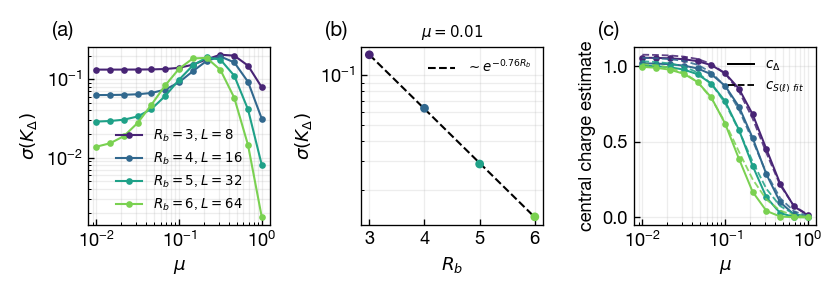

([(3, 0.01, 8, 1.057777496066228),
  (4, 0.01, 16, 1.020496843049737),
  (5, 0.01, 32, 1.0044838034915988),
  (6, 0.01, 64, 0.9970386485048375)],
 [{'depth': 3,
   'mu': 0.01,
   'L': 8,
   'arcs': (2, 2, 2, 2),
   'vfpe_raw': 0.1327267587068717,
   'vfpe_relative': 0.543075397186346,
   'c_estimate': 1.057777496066228,
   'c_raw_residual': 0.5744591960215898,
   'c_relative_residual': 0.5430813173450445},
  {'depth': 4,
   'mu': 0.01,
   'L': 16,
   'arcs': (4, 4, 4, 4),
   'vfpe_raw': 0.06288951739530932,
   'vfpe_relative': 0.26672407988048646,
   'c_estimate': 1.020496843049737,
   'c_raw_residual': 0.27199617090112765,
   'c_relative_residual': 0.2665330841085915},
  {'depth': 5,
   'mu': 0.01,
   'L': 32,
   'arcs': (8, 8, 8, 8),
   'vfpe_raw': 0.0288875555451655,
   'vfpe_relative': 0.12446982286678396,
   'c_estimate': 1.0044838034915988,
   'c_raw_residual': 0.12471319043424609,
   'c_relative_residual': 0.12415649709904869},
  {'depth': 6,
   'mu': 0.01,
   'L': 64,
   'arcs'

In [4]:
rows = []
for depth in tqdm(DEPTHS, desc="A5 VFPE R_b values"):
    for mu in tqdm(MU_VALUES, desc=f"R_b {depth} mu sweep", leave=False):
        rows.append(cached_vfpe_row(depth, mu))

k_delta_rows = [
    cached_vfpe_row(depth, FIXED_MU_FOR_CONVERGENCE)
    for depth in tqdm(CONVERGENCE_DEPTHS, desc="A5 fixed-mu convergence")
]

comparison_rows = []
for depth in tqdm(DEPTHS, desc="A5 c comparison R_b values"):
    for mu in tqdm(MU_VALUES, desc=f"R_b {depth} c comparison", leave=False):
        comparison_rows.append(cached_c_comparison_row(depth, mu))

bbox = Bbox.from_bounds(0, 0, 7.0, 2.45)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
fig, axes = plt.subplots(1, 3, figsize=(bbox.width, bbox.height), sharex=False)
colors = [plotting.color_for_depth(depth) for depth in DEPTHS]

for depth, color in zip(DEPTHS, colors):
    depth_rows = [row for row in rows if row["depth"] == depth]
    mu = np.asarray([row["mu"] for row in depth_rows])
    label = fr"$R_b={depth}$, $L={depth_rows[0]['L']}$"
    comparison_depth_rows = [row for row in comparison_rows if row["depth"] == depth]
    comparison_mu = np.asarray([row["mu"] for row in comparison_depth_rows], dtype=float)
    c_delta = np.asarray([row["c_delta"] for row in comparison_depth_rows], dtype=float)
    c_fit = np.asarray([row["c_from_entropy_fit"] for row in comparison_depth_rows], dtype=float)
    axes[0].plot(mu, [row["vfpe_raw"] for row in depth_rows], "o-", ms=3.0, lw=1.25, color=color, label=label)
    axes[2].plot(comparison_mu, c_delta, "o-", ms=3.0, lw=1.2, color=color, label=label)
    axes[2].plot(comparison_mu, c_fit, "--", lw=1.1, color=color, alpha=0.85)

axes[0].set_ylabel(r"$\sigma(K_\Delta)$")
axes[0].set_yscale("log")
axes[0].legend(frameon=False, fontsize=8, loc="best")

k_depths = np.asarray([row["depth"] for row in k_delta_rows], dtype=int)
k_raw = np.asarray([row["vfpe_raw"] for row in k_delta_rows], dtype=float)
point_colors = [plotting.color_for_depth(int(depth)) for depth in k_depths]
axes[1].scatter(k_depths, k_raw, s=18, color=point_colors, zorder=3)
fit_mask = np.isfinite(k_raw) & (k_raw > 0)
if np.count_nonzero(fit_mask) >= 2:
    slope, intercept = np.polyfit(k_depths[fit_mask], np.log(k_raw[fit_mask]), 1)
    fit_depths = np.linspace(float(np.min(k_depths[fit_mask])), float(np.max(k_depths[fit_mask])), 200)
    fit_values = np.exp(intercept + slope * fit_depths)
    axes[1].plot(
        fit_depths,
        fit_values,
        "--",
        lw=1.25,
        color="black",
        label=rf"$\sim e^{{{slope:.2f}R_b}}$",
    )
    axes[1].legend(frameon=False, fontsize=8, loc="best")
axes[1].set_ylabel(r"$\sigma(K_\Delta)$")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$R_b$")
axes[1].set_xticks(k_depths)
axes[1].set_title(rf"$\mu={FIXED_MU_FOR_CONVERGENCE:g}$", fontsize=9)

axes[2].set_ylabel(r"central charge estimate")
style_handles = [
    Line2D([0], [0], color="black", lw=1.2, ls="-", label=r"$c_\Delta$"),
    Line2D([0], [0], color="black", lw=1.1, ls="--", label=r"$c_{S(\ell)\ fit}$"),
]
axes[2].legend(handles=style_handles, frameon=False, fontsize=8, loc="upper right")

for index, axis in enumerate(axes):
    if index in (0, 2):
        axis.set_xscale("log")
        axis.set_xlabel(r"$\mu$")
    axis.grid(alpha=0.22, which="both")
    axis.text(-0.2, 1.06, f"({chr(ord('a') + index)})", transform=axis.transAxes, fontsize=subfigure_label_fontsize)

fig.tight_layout(w_pad=1.0)
save_figure_with_hash(fig, FIGURE_PATH)
plt.show()

[(row["depth"], row["mu"], row["L"], row["c_estimate"]) for row in rows if row["mu"] == MU_VALUES[0]], k_delta_rows


## Scratch Cells

## Scratch Cells

## Scratch Cells

## Diagnostic: Central-Charge Comparison

Plot additional central-charge comparison diagnostics. This diagnostic is not part of the main exported VFPE figure.

A5 c comparison R_b values:   0%|          | 0/4 [00:00<?, ?it/s]

R_b 3 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 4 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 5 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

R_b 6 c comparison:   0%|          | 0/13 [00:00<?, ?it/s]

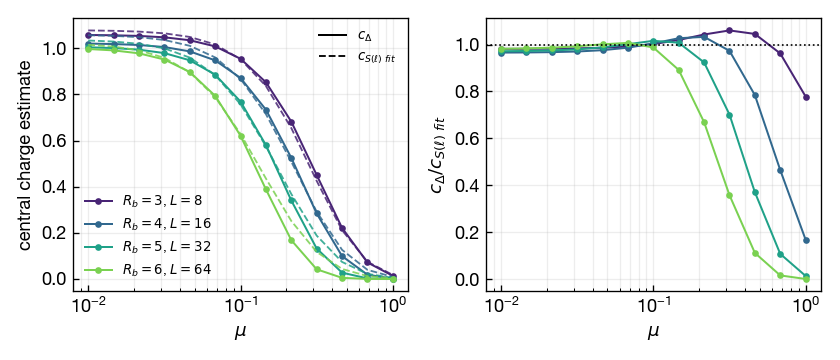

[{'depth': 3,
  'mu': 0.01,
  'L': 8,
  'c_delta': 1.057777496066228,
  'c_delta_raw_residual': 0.5744591960215898,
  'c_delta_relative_residual': 0.5430813173450445,
  'c_from_entropy_fit': 1.0775584173570125,
  'c_from_entropy_fit_stderr': 0.014426158860198851,
  'c_from_entropy_fit_offset': 3.6729016780239823},
 {'depth': 3,
  'mu': 0.014677992676220698,
  'L': 8,
  'c_delta': 1.0564766858433328,
  'c_delta_raw_residual': 0.5745867919713814,
  'c_delta_relative_residual': 0.5438707731753847,
  'c_from_entropy_fit': 1.0759342930799667,
  'c_from_entropy_fit_stderr': 0.014422067412923553,
  'c_from_entropy_fit_offset': 3.289402877497418}]

In [5]:
from matplotlib.lines import Line2D

comparison_rows = []
for depth in tqdm(DEPTHS, desc="A5 c comparison R_b values"):
    for mu in tqdm(MU_VALUES, desc=f"R_b {depth} c comparison", leave=False):
        comparison_rows.append(cached_c_comparison_row(depth, mu))

bbox = Bbox.from_bounds(0, 0, 7.0, 3.0)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
fig, (ax_compare, ax_ratio) = plt.subplots(1, 2, figsize=(bbox.width, bbox.height))

for depth in DEPTHS:
    depth_rows = [row for row in comparison_rows if row["depth"] == depth]
    color = plotting.color_for_depth(depth)
    mu = np.asarray([row["mu"] for row in depth_rows], dtype=float)
    c_delta = np.asarray([row["c_delta"] for row in depth_rows], dtype=float)
    c_fit = np.asarray([row["c_from_entropy_fit"] for row in depth_rows], dtype=float)
    label = fr"$R_b={depth}$, $L={depth_rows[0]['L']}$"
    ax_compare.plot(mu, c_delta, "o-", ms=3.0, lw=1.2, color=color, label=label)
    ax_compare.plot(mu, c_fit, "--", lw=1.1, color=color, alpha=0.85)
    ax_ratio.plot(mu, c_delta / c_fit, "o-", ms=3.0, lw=1.2, color=color, label=label)

ax_compare.set_xscale("log")
ax_compare.set_xlabel(r"$\mu$")
ax_compare.set_ylabel(r"central charge estimate")
ax_compare.grid(alpha=0.22, which="both")
rb_legend = ax_compare.legend(frameon=False, fontsize=8, loc="lower left")
ax_compare.add_artist(rb_legend)
style_handles = [
    Line2D([0], [0], color="black", lw=1.2, ls="-", label=r"$c_\Delta$"),
    Line2D([0], [0], color="black", lw=1.1, ls="--", label=r"$c_{S(\ell)\ fit}$"),
]
ax_compare.legend(handles=style_handles, frameon=False, fontsize=8, loc="upper right")

ax_ratio.axhline(1.0, color="black", lw=1.0, ls=":")
ax_ratio.set_xscale("log")
ax_ratio.set_xlabel(r"$\mu$")
ax_ratio.set_ylabel(r"$c_\Delta/c_{S(\ell)\ fit}$")
ax_ratio.grid(alpha=0.22, which="both")

fig.tight_layout()
save_figure_with_hash(fig, COMPARISON_FIGURE_PATH)
plt.show()
comparison_rows[:2]


